# Genomic Biomarker Discovery for Breast Cancer Using Machine Learning and Cloud Computing

In [1]:
import pandas as pd
import numpy as np

In [2]:
!rm /content/TCGA-BRCA.star_tpm.tsv.gz

In [3]:
!wget -O TCGA-BRCA.star_tpm.tsv.gz "https://gdc-hub.s3.us-east-1.amazonaws.com/download/TCGA-BRCA.star_tpm.tsv.gz"

--2026-05-21 14:23:39--  https://gdc-hub.s3.us-east-1.amazonaws.com/download/TCGA-BRCA.star_tpm.tsv.gz
Resolving gdc-hub.s3.us-east-1.amazonaws.com (gdc-hub.s3.us-east-1.amazonaws.com)... 52.217.192.74, 52.216.52.218, 16.15.183.147, ...
Connecting to gdc-hub.s3.us-east-1.amazonaws.com (gdc-hub.s3.us-east-1.amazonaws.com)|52.217.192.74|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 342300776 (326M) [text/tab-separated-values]
Saving to: ‘TCGA-BRCA.star_tpm.tsv.gz’

TCGA-BRCA.star_tpm. 100%[===================>] 326.44M  31.7MB/s    in 9.5s    

2026-05-21 14:23:48 (34.5 MB/s) - ‘TCGA-BRCA.star_tpm.tsv.gz’ saved [342300776/342300776]



In [4]:
expr = pd.read_csv(
    "TCGA-BRCA.star_tpm.tsv.gz",
    sep="\t",
    compression='gzip',
    index_col=0
)

expr.head()

,TCGA-D8-A146-01A,TCGA-AQ-A0Y5-01A,TCGA-C8-A274-01A,TCGA-BH-A0BD-01A,TCGA-B6-A1KC-01B,TCGA-AC-A62V-01A,TCGA-AO-A0J5-01A,TCGA-BH-A0B1-01A,TCGA-A2-A0YM-01A,TCGA-AO-A03N-01B,...,TCGA-E2-A1IG-01A,TCGA-E9-A1NA-01A,TCGA-D8-A1JP-01A,TCGA-AR-A252-01A,TCGA-D8-A1XL-01A,TCGA-BH-A0EI-01A,TCGA-E2-A1IO-01A,TCGA-E2-A15R-01A,TCGA-B6-A0IP-01A,TCGA-A1-A0SN-01A
Ensembl_ID,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003.15,5.662037,3.703721,6.514515,4.784917,4.251984,3.536849,4.645690,6.021755,6.260931,3.613025,...,4.825501,4.142806,4.960919,4.770121,5.276757,6.436490,6.184500,2.670931,6.834395,3.650719
ENSG00000000005.6,3.376096,0.463099,0.000000,2.328061,0.435415,0.736475,1.255622,0.392647,0.467593,0.000000,...,0.134747,0.159500,0.079566,3.312418,0.000000,0.383608,0.755144,0.479644,0.526069,0.059909
ENSG00000000419.13,6.860140,7.086452,6.805072,6.443071,6.178436,6.823355,5.749910,6.977449,6.819887,6.079559,...,6.382933,6.436308,6.994589,6.005000,7.382161,7.220846,6.868277,7.033110,6.384368,8.153019
ENSG00000000457.14,4.400552,4.051007,5.037264,4.374970,3.558464,2.108324,4.487107,4.021000,3.319560,2.287502,...,3.891448,3.765057,4.946796,3.648707,3.664915,3.752192,4.093078,4.831796,4.368028,4.172247
ENSG00000000460.17,2.845169,2.426989,4.043248,4.162790,2.589548,2.277777,2.545178,3.372492,4.023974,1.753177,...,2.557655,2.566596,3.746915,2.494160,3.104957,3.111549,2.538538,3.730901,3.311721,3.301075


In [ ]:
# !wget -O TCGA-BRCA.clinical.tsv.gz "https://gdc-hub.s3.us-east-1.amazonaws.com/download/TCGA-BRCA.clinical.tsv.gz"

In [ ]:
# clinical = pd.read_csv(
#     "TCGA-BRCA.clinical.tsv.gz",
#     sep="\t",
#     compression='gzip'
# )

# clinical.head()

In [5]:
print(expr.shape)
expr.head()

(60660, 1226)


,TCGA-D8-A146-01A,TCGA-AQ-A0Y5-01A,TCGA-C8-A274-01A,TCGA-BH-A0BD-01A,TCGA-B6-A1KC-01B,TCGA-AC-A62V-01A,TCGA-AO-A0J5-01A,TCGA-BH-A0B1-01A,TCGA-A2-A0YM-01A,TCGA-AO-A03N-01B,...,TCGA-E2-A1IG-01A,TCGA-E9-A1NA-01A,TCGA-D8-A1JP-01A,TCGA-AR-A252-01A,TCGA-D8-A1XL-01A,TCGA-BH-A0EI-01A,TCGA-E2-A1IO-01A,TCGA-E2-A15R-01A,TCGA-B6-A0IP-01A,TCGA-A1-A0SN-01A
Ensembl_ID,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003.15,5.662037,3.703721,6.514515,4.784917,4.251984,3.536849,4.645690,6.021755,6.260931,3.613025,...,4.825501,4.142806,4.960919,4.770121,5.276757,6.436490,6.184500,2.670931,6.834395,3.650719
ENSG00000000005.6,3.376096,0.463099,0.000000,2.328061,0.435415,0.736475,1.255622,0.392647,0.467593,0.000000,...,0.134747,0.159500,0.079566,3.312418,0.000000,0.383608,0.755144,0.479644,0.526069,0.059909
ENSG00000000419.13,6.860140,7.086452,6.805072,6.443071,6.178436,6.823355,5.749910,6.977449,6.819887,6.079559,...,6.382933,6.436308,6.994589,6.005000,7.382161,7.220846,6.868277,7.033110,6.384368,8.153019
ENSG00000000457.14,4.400552,4.051007,5.037264,4.374970,3.558464,2.108324,4.487107,4.021000,3.319560,2.287502,...,3.891448,3.765057,4.946796,3.648707,3.664915,3.752192,4.093078,4.831796,4.368028,4.172247
ENSG00000000460.17,2.845169,2.426989,4.043248,4.162790,2.589548,2.277777,2.545178,3.372492,4.023974,1.753177,...,2.557655,2.566596,3.746915,2.494160,3.104957,3.111549,2.538538,3.730901,3.311721,3.301075


In [ ]:
# print(clinical.shape)
# # clinical.head()

In [ ]:
# expr = expr.set_index(expr.columns[0])

In [ ]:
# expr.head()

In [6]:
expr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60660 entries, ENSG00000000003.15 to ENSG00000288675.1
Columns: 1226 entries, TCGA-D8-A146-01A to TCGA-A1-A0SN-01A
dtypes: float64(1226)
memory usage: 567.9+ MB


In [ ]:
# clinical.info()

In [7]:
expr_t = expr.T

In [8]:
expr_t.shape

(1226, 60660)

In [9]:
expr_t['sample_id'] = expr_t.index

expr_t['sample_type_code'] = (
    expr_t['sample_id']
    .str[13:15]
)

expr_t = expr_t[
    expr_t['sample_type_code']
    .isin(['01', '11'])
]

expr_t['label'] = (
    expr_t['sample_type_code'] == '01'
).astype(int)

In [10]:


print(expr_t['label'].value_counts())


label
1    1106
0     113
Name: count, dtype: int64


In [11]:
expr_t.head()

Ensembl_ID,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1,sample_id,sample_type_code,label
TCGA-D8-A146-01A,5.662037,3.376096,6.860140,4.400552,2.845169,3.579965,4.996181,5.614683,4.385652,5.843705,...,0.0,0.000000,0.0,3.533999,0.0,0.058109,1.122739,TCGA-D8-A146-01A,01,1
TCGA-AQ-A0Y5-01A,3.703721,0.463099,7.086452,4.051007,2.426989,2.322361,4.943860,6.539078,4.046404,5.711726,...,0.0,0.000000,0.0,4.773448,0.0,0.054779,1.243182,TCGA-AQ-A0Y5-01A,01,1
TCGA-C8-A274-01A,6.514515,0.000000,6.805072,5.037264,4.043248,2.124130,2.993348,5.119912,3.409907,5.963742,...,0.0,0.000000,0.0,4.701710,0.0,0.093425,0.604261,TCGA-C8-A274-01A,01,1
TCGA-BH-A0BD-01A,4.784917,2.328061,6.443071,4.374970,4.162790,3.122375,4.754674,5.608738,3.625691,5.678199,...,0.0,0.966357,0.0,4.689075,0.0,0.059771,0.536351,TCGA-BH-A0BD-01A,01,1
TCGA-B6-A1KC-01B,4.251984,0.435415,6.178436,3.558464,2.589548,1.508581,3.722149,5.224044,3.242221,5.956145,...,0.0,0.000000,0.0,5.168221,0.0,0.023752,0.389126,TCGA-B6-A1KC-01B,01,1


In [12]:

# GENE COLUMNS
gene_cols = [
    col for col in expr_t.columns
    if col.startswith('ENSG')
]

print("Gene columns:",
      len(gene_cols))


Gene columns: 60660


In [13]:

# LOG2 TPM TRANSFORMATION
expr_t[gene_cols] = np.log2(
    expr_t[gene_cols] + 1
)

print("Log transform complete.")

Log transform complete.


In [15]:
expr_t.head()

Ensembl_ID,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1,sample_id,sample_type_code,label
TCGA-D8-A146-01A,2.735963,2.129644,2.974555,2.433107,1.943047,2.195336,2.584044,2.725672,2.429121,2.774778,...,0.0,0.000000,0.0,2.180784,0.0,0.081488,1.085927,TCGA-D8-A146-01A,01,1
TCGA-AQ-A0Y5-01A,2.233802,0.549028,3.015507,2.336571,1.776942,1.732209,2.571400,2.914388,2.335256,2.746684,...,0.0,0.000000,0.0,2.529433,0.0,0.076941,1.165546,TCGA-AQ-A0Y5-01A,01,1
TCGA-C8-A274-01A,2.909680,0.000000,2.964412,2.593895,2.334353,1.643454,1.997599,2.613511,2.140748,2.799863,...,0.0,0.000000,0.0,2.511395,0.0,0.128854,0.681909,TCGA-C8-A274-01A,01,1
TCGA-BH-A0BD-01A,2.532296,1.734682,2.895898,2.426257,2.368151,2.043476,2.524734,2.724375,2.209669,2.739459,...,0.0,0.975525,0.0,2.508194,0.0,0.083752,0.619508,TCGA-BH-A0BD-01A,01,1
TCGA-B6-A1KC-01B,2.392863,0.521468,2.843670,2.188548,1.843802,1.326871,2.239444,2.637852,2.084820,2.798288,...,0.0,0.000000,0.0,2.624854,0.0,0.033866,0.474178,TCGA-B6-A1KC-01B,01,1


In [14]:
print(expr_t.shape)

# SAVE CLEAN ML DATASET
expr_t.to_csv(
    "brca_clean_ml_dataset.csv",
    index=False
)

print("Dataset saved.")

(1219, 60663)
Dataset saved.


In [16]:


import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report
)

# LOAD CLEAN DATASET
df = pd.read_csv(
    "brca_clean_ml_dataset.csv"
)

print(df.shape)



(1219, 60663)


In [17]:
# =========================================================
# GENE COLUMNS
# =========================================================

gene_cols = [
    col for col in df.columns
    if col.startswith('ENSG')
]

X = df[gene_cols]

y = df['label']

print(X.shape)

print(
    y.value_counts()
)



(1219, 60660)
label
1    1106
0     113
Name: count, dtype: int64


In [18]:
# =========================================================
# STRATIFIED K-FOLD
# =========================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)



In [19]:
# =========================================================
# METRIC STORAGE
# =========================================================

lr_acc_scores = []
lr_auc_scores = []

lasso_acc_scores = []
lasso_auc_scores = []

rf_acc_scores = []
rf_auc_scores = []

# =========================================================
# MAIN LOOP
# =========================================================

fold = 1

for train_idx, val_idx in skf.split(X, y):

    print(f"\n========== Fold {fold} ==========")

    # -----------------------------------------------------
    # SPLIT
    # -----------------------------------------------------

    X_train = X.iloc[train_idx]

    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]

    y_val = y.iloc[val_idx]

    print(
        "y_Train:",
        y_train.value_counts()
    )
    print(
        "y_val:",
        y_val.value_counts()
    )
    # SCALE DATA

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        X_train
    )

    X_val_scaled = scaler.transform(
        X_val
    )

    # LOGISTIC REGRESSION

    lr_model = LogisticRegression(
        max_iter=5000,
        n_jobs=-1
    )

    lr_model.fit(
        X_train_scaled,
        y_train
    )

    lr_pred = lr_model.predict(
        X_val_scaled
    )

    lr_prob = lr_model.predict_proba(
        X_val_scaled
    )[:,1]

    lr_acc = accuracy_score(
        y_val,
        lr_pred
    )

    lr_auc = roc_auc_score(
        y_val,
        lr_prob
    )

    lr_acc_scores.append(
        lr_acc
    )

    lr_auc_scores.append(
        lr_auc
    )

    print(
        f"LR Accuracy: {lr_acc:.4f}"
    )

    print(
        f"LR ROC-AUC: {lr_auc:.4f}"
    )


    # LASSO LOGISTIC REGRESSION

    lasso_model = LogisticRegression(
        penalty='l1',
        solver='liblinear',
        C=1.0,
        max_iter=5000
    )

    lasso_model.fit(
        X_train_scaled,
        y_train
    )

    lasso_pred = lasso_model.predict(
        X_val_scaled
    )

    lasso_prob = lasso_model.predict_proba(
        X_val_scaled
    )[:,1]

    lasso_acc = accuracy_score(
        y_val,
        lasso_pred
    )

    lasso_auc = roc_auc_score(
        y_val,
        lasso_prob
    )

    lasso_acc_scores.append(
        lasso_acc
    )

    lasso_auc_scores.append(
        lasso_auc
    )

    print(
        f"LASSO Accuracy: {lasso_acc:.4f}"
    )

    print(
        f"LASSO ROC-AUC: {lasso_auc:.4f}"
    )


    # RANDOM FOREST
    rf_model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    rf_model.fit(
        X_train,
        y_train
    )

    rf_pred = rf_model.predict(
        X_val
    )

    rf_prob = rf_model.predict_proba(
        X_val
    )[:,1]

    rf_acc = accuracy_score(
        y_val,
        rf_pred
    )

    rf_auc = roc_auc_score(
        y_val,
        rf_prob
    )

    rf_acc_scores.append(
        rf_acc
    )

    rf_auc_scores.append(
        rf_auc
    )

    print(
        f"RF Accuracy: {rf_acc:.4f}"
    )

    print(
        f"RF ROC-AUC: {rf_auc:.4f}"
    )

    # NEXT FOLD
    fold += 1




========== Fold 1 ==========
y_Train: label
1    884
0     91
Name: count, dtype: int64
y_val: label
1    222
0     22
Name: count, dtype: int64
LR Accuracy: 0.9959
LR ROC-AUC: 1.0000
LASSO Accuracy: 1.0000
LASSO ROC-AUC: 1.0000
RF Accuracy: 0.9918
RF ROC-AUC: 0.9998

========== Fold 2 ==========
y_Train: label
1    885
0     90
Name: count, dtype: int64
y_val: label
1    221
0     23
Name: count, dtype: int64
LR Accuracy: 0.9877
LR ROC-AUC: 0.9996
LASSO Accuracy: 0.9959
LASSO ROC-AUC: 1.0000
RF Accuracy: 0.9877
RF ROC-AUC: 0.9998

========== Fold 3 ==========
y_Train: label
1    885
0     90
Name: count, dtype: int64
y_val: label
1    221
0     23
Name: count, dtype: int64
LR Accuracy: 0.9795
LR ROC-AUC: 0.9994
LASSO Accuracy: 0.9959
LASSO ROC-AUC: 0.9996
RF Accuracy: 0.9918
RF ROC-AUC: 0.9990

========== Fold 4 ==========
y_Train: label
1    885
0     90
Name: count, dtype: int64
y_val: label
1    221
0     23
Name: count, dtype: int64
LR Accuracy: 0.9713
LR ROC-AUC: 0.9984
LASSO Ac

In [20]:

# FINAL RESULTS

print("\n========== FINAL RESULTS ==========")

print("\nLogistic Regression")

print(
    "Mean Accuracy:",
    np.mean(lr_acc_scores)
)

print(
    "Mean ROC-AUC:",
    np.mean(lr_auc_scores)
)

print("\nLASSO Logistic Regression")

print(
    "Mean Accuracy:",
    np.mean(lasso_acc_scores)
)

print(
    "Mean ROC-AUC:",
    np.mean(lasso_auc_scores)
)

print("\nRandom Forest")

print(
    "Mean Accuracy:",
    np.mean(rf_acc_scores)
)

print(
    "Mean ROC-AUC:",
    np.mean(rf_auc_scores)
)


========== FINAL RESULTS ==========

Logistic Regression
Mean Accuracy: 0.9835930648316804
Mean ROC-AUC: 0.9994473557133403

LASSO Logistic Regression
Mean Accuracy: 0.9967179383390677
Mean ROC-AUC: 0.9997227836102518

Random Forest
Mean Accuracy: 0.9885212170275922
Mean ROC-AUC: 0.9990075717697202


In [21]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [22]:
# TRAIN FINAL LASSO MODEL
lasso_model = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=1.0,
    max_iter=5000
)

lasso_model.fit(
    X_scaled,
    y
)

print("LASSO model trained.")

LASSO model trained.


In [23]:

coefficients = pd.DataFrame({
    'gene': gene_cols,
    'coefficient': lasso_model.coef_[0]
})

In [28]:
# =========================================================
# ABSOLUTE COEFFICIENT MAGNITUDE
# =========================================================

coefficients['abs_coef'] = abs(
    coefficients['coefficient']
)

# =========================================================
# REMOVE ZERO COEFFICIENTS
# =========================================================

lasso_biomarkers = coefficients[
    coefficients['coefficient'] != 0
]

# =========================================================
# SORT BY IMPORTANCE
# =========================================================

lasso_biomarkers = lasso_biomarkers.sort_values(
    by='abs_coef',
    ascending=False
)

print(lasso_biomarkers.head(20))

                     gene  coefficient  abs_coef
5393   ENSG00000123500.10     0.300620  0.300620
2919   ENSG00000104415.14     0.214302  0.214302
17476  ENSG00000197614.11    -0.198608  0.198608
3159   ENSG00000105664.11     0.172239  0.172239
39641   ENSG00000251325.1    -0.171005  0.171005
45674   ENSG00000260102.2    -0.163502  0.163502
28369   ENSG00000228868.3    -0.151377  0.151377
43925   ENSG00000257766.1    -0.146908  0.146908
54469   ENSG00000277743.1     0.138868  0.138868
28557   ENSG00000229168.4    -0.132856  0.132856
14008   ENSG00000176115.9    -0.129836  0.129836
29723   ENSG00000230838.1     0.129422  0.129422
38053   ENSG00000248869.7    -0.126337  0.126337
30544   ENSG00000232079.7    -0.126018  0.126018
16366   ENSG00000186971.3    -0.125674  0.125674
10742   ENSG00000162494.6    -0.125669  0.125669
328     ENSG00000013293.6    -0.121424  0.121424
20926   ENSG00000207249.1     0.120624  0.120624
15255  ENSG00000182492.16     0.118272  0.118272
2140   ENSG000000999

In [29]:
lasso_biomarkers[
    lasso_biomarkers['coefficient'] > 0
]

,gene,coefficient,abs_coef
5393,ENSG00000123500.10,0.300620,0.300620
2919,ENSG00000104415.14,0.214302,0.214302
3159,ENSG00000105664.11,0.172239,0.172239
54469,ENSG00000277743.1,0.138868,0.138868
29723,ENSG00000230838.1,0.129422,0.129422
...,...,...,...
7084,ENSG00000135451.13,0.002778,0.002778
20957,ENSG00000207290.1,0.002645,0.002645
38644,ENSG00000249825.6,0.001620,0.001620
42782,ENSG00000255357.2,0.000811,0.000811


In [30]:
lasso_biomarkers[
    lasso_biomarkers['coefficient'] < 0
]

,gene,coefficient,abs_coef
17476,ENSG00000197614.11,-0.198608,0.198608
39641,ENSG00000251325.1,-0.171005,0.171005
45674,ENSG00000260102.2,-0.163502,0.163502
28369,ENSG00000228868.3,-0.151377,0.151377
43925,ENSG00000257766.1,-0.146908,0.146908
...,...,...,...
50075,ENSG00000269289.6,-0.002353,0.002353
57205,ENSG00000283788.1,-0.001873,0.001873
13725,ENSG00000174611.12,-0.001085,0.001085
37421,ENSG00000246022.3,-0.000979,0.000979


In [31]:
# =========================================================
# TUMOR BIOMARKERS
# =========================================================

tumor_biomarkers = lasso_biomarkers[
    lasso_biomarkers['coefficient'] > 0
]

tumor_biomarkers.to_csv(
    "tumor_biomarkers.csv",
    index=False
)

print(
    tumor_biomarkers.head(20)
)

                     gene  coefficient  abs_coef
5393   ENSG00000123500.10     0.300620  0.300620
2919   ENSG00000104415.14     0.214302  0.214302
3159   ENSG00000105664.11     0.172239  0.172239
54469   ENSG00000277743.1     0.138868  0.138868
29723   ENSG00000230838.1     0.129422  0.129422
20926   ENSG00000207249.1     0.120624  0.120624
15255  ENSG00000182492.16     0.118272  0.118272
2140   ENSG00000099953.10     0.116981  0.116981
59577   ENSG00000287171.1     0.113117  0.113117
30918   ENSG00000232636.2     0.104245  0.104245
57318   ENSG00000284032.1     0.091543  0.091543
4746   ENSG00000117650.13     0.088993  0.088993
56373   ENSG00000280832.1     0.079189  0.079189
12801   ENSG00000170369.4     0.077167  0.077167
19660  ENSG00000203805.11     0.071341  0.071341
15601  ENSG00000183856.11     0.064457  0.064457
38549   ENSG00000249667.1     0.064171  0.064171
26420   ENSG00000226008.1     0.061059  0.061059
7021   ENSG00000135127.11     0.058952  0.058952
51695   ENSG00000272

In [32]:
# =========================================================
# NORMAL BIOMARKERS
# =========================================================

normal_biomarkers = lasso_biomarkers[
    lasso_biomarkers['coefficient'] < 0
]

normal_biomarkers.to_csv(
    "normal_biomarkers.csv",
    index=False
)

print(
    normal_biomarkers.head(20)
)

                     gene  coefficient  abs_coef
17476  ENSG00000197614.11    -0.198608  0.198608
39641   ENSG00000251325.1    -0.171005  0.171005
45674   ENSG00000260102.2    -0.163502  0.163502
28369   ENSG00000228868.3    -0.151377  0.151377
43925   ENSG00000257766.1    -0.146908  0.146908
28557   ENSG00000229168.4    -0.132856  0.132856
14008   ENSG00000176115.9    -0.129836  0.129836
38053   ENSG00000248869.7    -0.126337  0.126337
30544   ENSG00000232079.7    -0.126018  0.126018
16366   ENSG00000186971.3    -0.125674  0.125674
10742   ENSG00000162494.6    -0.125669  0.125669
328     ENSG00000013293.6    -0.121424  0.121424
20365   ENSG00000206172.8    -0.107729  0.107729
26803   ENSG00000226542.1    -0.107321  0.107321
16813  ENSG00000188828.12    -0.100974  0.100974
54575   ENSG00000277954.1    -0.093863  0.093863
516    ENSG00000034971.17    -0.091814  0.091814
16946  ENSG00000189367.15    -0.080635  0.080635
26007   ENSG00000225396.5    -0.078913  0.078913
60059   ENSG00000287

In [33]:
# =========================================================
# TOP 20 BIOMARKERS
# =========================================================

top20_genes = lasso_biomarkers[
    'gene'
].head(20).tolist()

print(top20_genes)

['ENSG00000123500.10', 'ENSG00000104415.14', 'ENSG00000197614.11', 'ENSG00000105664.11', 'ENSG00000251325.1', 'ENSG00000260102.2', 'ENSG00000228868.3', 'ENSG00000257766.1', 'ENSG00000277743.1', 'ENSG00000229168.4', 'ENSG00000176115.9', 'ENSG00000230838.1', 'ENSG00000248869.7', 'ENSG00000232079.7', 'ENSG00000186971.3', 'ENSG00000162494.6', 'ENSG00000013293.6', 'ENSG00000207249.1', 'ENSG00000182492.16', 'ENSG00000099953.10']


In [34]:
# =========================================================
# HEATMAP DATA
# =========================================================

heatmap_df = df[
    top20_genes
]

# =========================================================
# SAMPLE COLORS
# =========================================================

sample_colors = df['label'].map({
    1: 'red',
    0: 'blue'
})

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


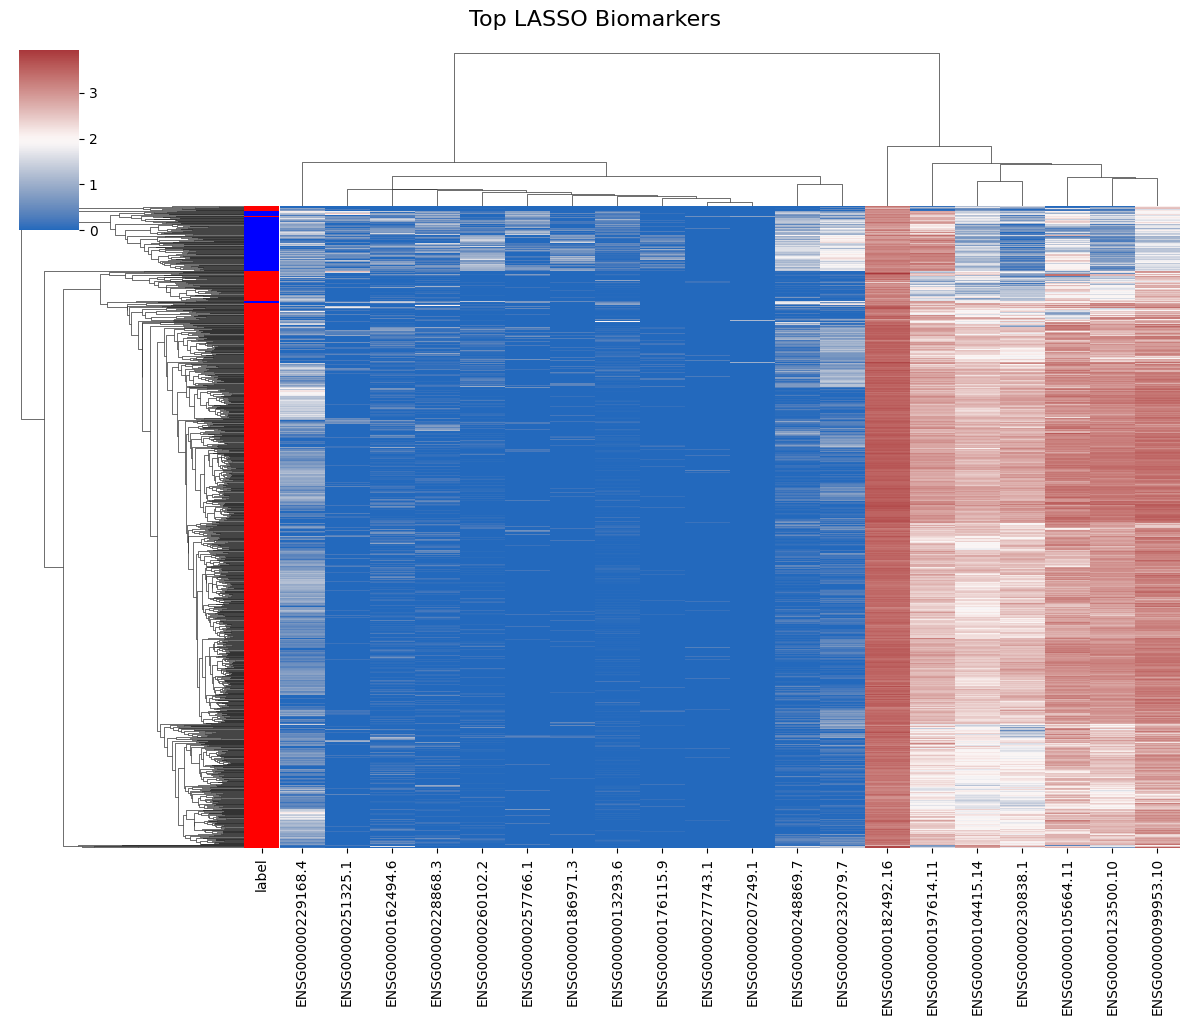

In [35]:
# =========================================================
# CLUSTERED HEATMAP
# =========================================================

import seaborn as sns
import matplotlib.pyplot as plt

g = sns.clustermap(
    heatmap_df,
    row_colors=sample_colors,
    cmap='vlag',
    figsize=(12,10),
    xticklabels=True,
    yticklabels=False
)

g.fig.suptitle(
    "Top LASSO Biomarkers",
    y=1.02,
    fontsize=16
)

plt.savefig(
    "lasso_biomarker_heatmap.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()